In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [5]:
df = pd.read_csv('creditcard.csv')

print(f"📦 Rows: {df.shape[0]:,}")
print(f"📊 Columns: {df.shape[1]}")
df.head()

📦 Rows: 284,807
📊 Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


=== CLASS DISTRIBUTION ===
               Count  Percentage
✅ Normal (0)  284315     99.8270
🚨 Fraud (1)      492      0.1730


C:\Users\agusm\AppData\Local\Temp\ipykernel_2316\812035248.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Normal', 'Fraud'], y=count.values, palette=['steelblue', 'crimson'])


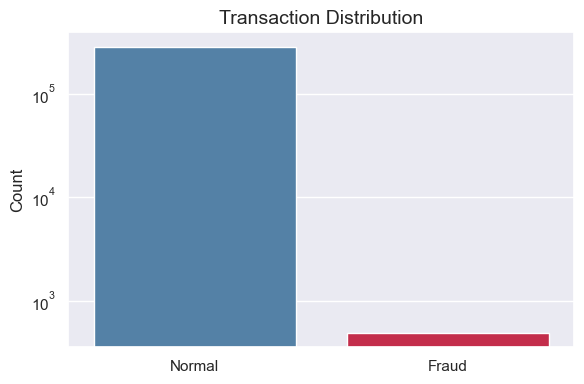

In [6]:
count = df['Class'].value_counts()
percentage = df['Class'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': count,
    'Percentage': percentage.round(3)
})
summary.index = ['✅ Normal (0)', '🚨 Fraud (1)']
print("=== CLASS DISTRIBUTION ===")
print(summary)

plt.figure(figsize=(6, 4))
sns.barplot(x=['Normal', 'Fraud'], y=count.values, palette=['steelblue', 'crimson'])
plt.title('Transaction Distribution', fontsize=14)
plt.ylabel('Count')
plt.yscale('log')
plt.tight_layout()
plt.show()

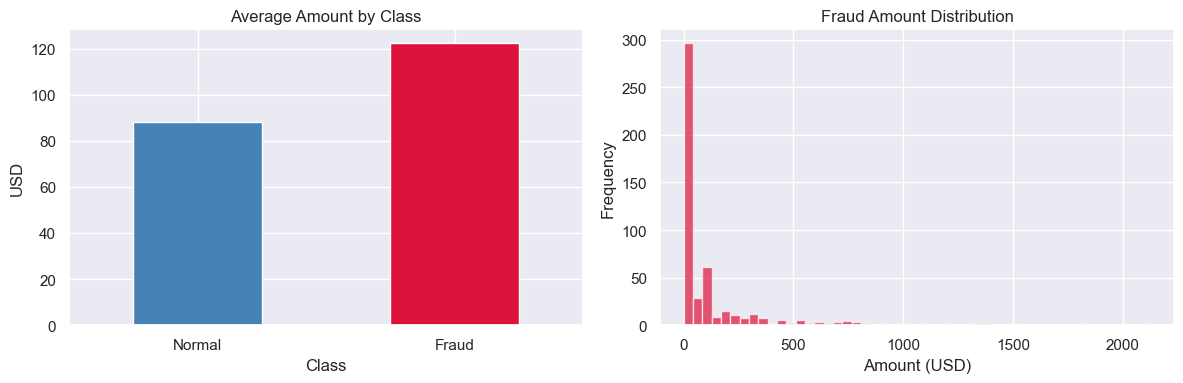

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('Class')['Amount'].mean().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'crimson'], rot=0
)
axes[0].set_title('Average Amount by Class')
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_ylabel('USD')

df[df['Class'] == 1]['Amount'].plot(
    kind='hist', bins=50, ax=axes[1], color='crimson', alpha=0.7
)
axes[1].set_title('Fraud Amount Distribution')
axes[1].set_xlabel('Amount (USD)')

plt.tight_layout()
plt.show()

When looking at the transaction amounts, I found something really interesting that sounds like a contradiction but actually makes perfect sense from an economic perspective.

First, the average fraud amount is higher than the average for normal transactions ($122 vs $88). This happens because of outliers—a few massive fraudulent charges that pull the mean upward.

However, when you look at the big picture, the vast majority of frauds are actually small amounts, mostly under $500. This is a classic 'smurfing' or 'ant-run' strategy. Scammers start with small, low-profile charges to stay under the radar and avoid triggering bank alerts before they try anything bigger.

For my model, this means I can't just rely on the transaction size to catch fraud. I need to look at deeper patterns and use robust scaling to make sure those outliers don't mess up the predictions.